
--- SLOPE GEOMETRY INPUTS ---


Enter the Height of the cut slope (m) :  5
Enter the Angle of the cut slope (deg):  36
Enter the Height of the natural slope (m) (Extra height above crest):  10
Enter the Angle of the natural slope (deg):  6



--- SOIL PROPERTIES INPUTS ---


Enter Soil Cohesion (kPa) :  6
Enter Friction Angle (deg):  26
Enter Unit Weight (kN/m^3):  20



(Hint: 0 = Dry, 0.25 = Partial Saturation, 0.5 = Fully Saturated)


Enter Pore Pressure Ratio (Ru):  .25



--- ANALYSIS ACCURACY LEVEL ---
1. Average   (30 slices, Fast computation)
2. Fine      (50 slices, Slower but more accurate)
3. Very Fine (100 slices, Dense search grid, Slowest)


Select accuracy (1/2/3):  1



-> Selected AVERAGE accuracy. Searching...

CRITICAL FACTOR OF SAFETY : 1.789
Computed in               : 0.2 seconds
Total Slices Used         : 30
Center : X = 20.00, Y = 20.00, Radius = 23.77


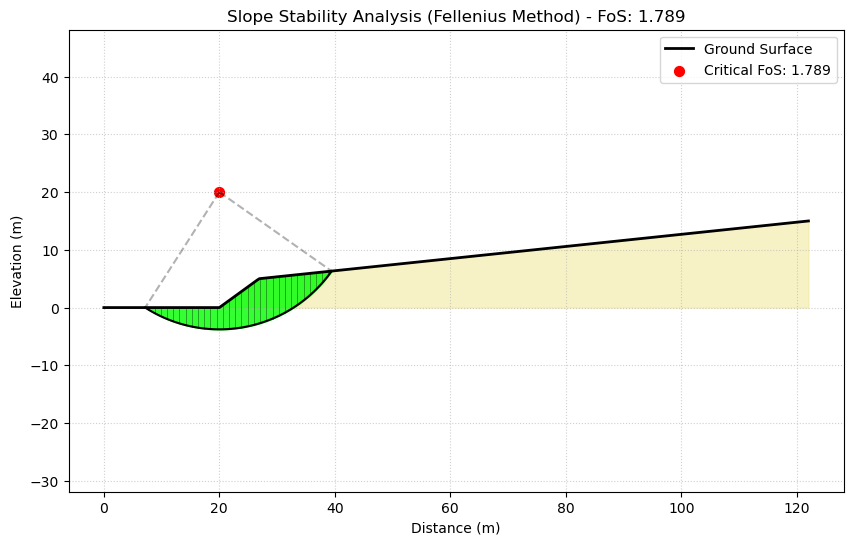


✅ Analysis Complete. Plot image saved locally as 'Slope_Stability_Result.png'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# ====================================================================
# 1. GEOMETRY GENERATOR (Stops at crest of natural slope)
# ====================================================================
def create_slope_geometry(H_cut, cut_angle_deg, H_nat, nat_angle_deg):
    """
    Creates the x, y coordinates starting from 0,0 based on heights and angles.
    Generates exactly up to the crest of the natural slope.
    """
    # 1. Flat ground at the toe
    x_toe_start = 0.0
    x_toe_end = 20.0  # 20m of flat ground before the slope starts
    p1 = (x_toe_start, 0.0)
    p2 = (x_toe_end, 0.0)
    
    # 2. Cut slope face
    if cut_angle_deg <= 0 or cut_angle_deg >= 90:
        raise ValueError("Cut slope angle must be between 0 and 90 degrees.")
        
    dx_cut = H_cut / np.tan(np.radians(cut_angle_deg))
    x_crest = x_toe_end + dx_cut
    p3 = (x_crest, H_cut)
    
    # 3. Natural slope above the crest
    if H_nat > 0 and nat_angle_deg > 0:
        if nat_angle_deg >= 90:
            raise ValueError("Natural slope angle must be less than 90 degrees.")
        dx_nat = H_nat / np.tan(np.radians(nat_angle_deg))
        x_top = x_crest + dx_nat
        y_top = H_cut + H_nat
    else:
        # If no natural slope, just extend flat slightly
        x_top = x_crest + 10.0
        y_top = H_cut
    p4 = (x_top, y_top)
    
    # Return exactly 4 points (stops at top of natural crest)
    return [p1, p2, p3, p4]


# ====================================================================
# 2. FELLENIUS ENGINE (Method of Slices)
# ====================================================================
class SlopeStabilityAnalyzer:
    def __init__(self, terrain_points, c, phi_deg, gamma, ru):
        self.points = sorted(terrain_points, key=lambda p: p[0])
        self.xs = np.array([p[0] for p in self.points])
        self.ys = np.array([p[1] for p in self.points])
        
        self.H_total = np.max(self.ys) - np.min(self.ys)
        self.W_total = np.max(self.xs) - np.min(self.xs)
            
        self.c = c
        self.phi = np.radians(phi_deg)
        self.gamma = gamma
        self.ru = ru
        
        # Identify the toe and crest x-coordinates for constraints
        self.x_toe = self.xs[1]
        self.x_crest = self.xs[2]

    def generate_auto_grid(self, resolution):
        xc_range = (self.x_toe, self.xs[-1])
        yc_range = (np.max(self.ys) + 5, np.max(self.ys) + 2.5 * self.H_total)
        R_range = (0.5 * self.H_total, 3.0 * self.H_total)
        step = max(self.H_total, self.W_total) / resolution
        return xc_range, yc_range, R_range, step

    def find_entry_exit(self, xc, yc, R):
        if yc - R > np.min(self.ys): return None, None

        x_scan = np.linspace(self.xs[0], self.xs[-1], 500)
        gy = np.interp(x_scan, self.xs, self.ys)
        
        rad_term = R**2 - (x_scan - xc)**2
        valid = rad_term >= 0
        if not np.any(valid): return None, None
            
        cy = np.full_like(x_scan, np.nan)
        cy[valid] = yc - np.sqrt(rad_term[valid])
        
        diff = gy - cy
        inside = diff > 0
        crossings = np.where(np.diff(inside))[0]
        
        if len(crossings) < 2: return None, None 
            
        x1_idx, x2_idx = crossings[0], crossings[-1]
        
        def exact_intersect(idx):
            x_a, x_b = x_scan[idx], x_scan[idx+1]
            d_a, d_b = diff[idx], diff[idx+1]
            return x_a - d_a * (x_b - x_a) / (d_b - d_a + 1e-12)
            
        return exact_intersect(x1_idx), exact_intersect(x2_idx)

    def calculate_fos(self, xc, yc, R, limit_entry_exit=True, n_slices=30):
        x_start, x_end = self.find_entry_exit(xc, yc, R)
        if x_start is None: return float('inf')

        # ENTRY/EXIT LIMITS (Forces Toe Breakout)
        if limit_entry_exit:
            if x_start > self.x_toe + 5: return float('inf') 
            if x_end < self.x_crest: return float('inf')

        # Ensure the slice has meaningful depth
        x_check = np.linspace(x_start, x_end, 10)
        y_check = np.interp(x_check, self.xs, self.ys)
        if np.max(y_check) - np.min(y_check) < 0.05 * self.H_total:
            return float('inf')

        dx = (x_end - x_start) / n_slices
        resisting_sum = driving_sum = 0.0
        slices_data = []

        for i in range(n_slices):
            xm = x_start + i * dx + (dx / 2)
            sin_alpha = np.clip((xm - xc) / R, -0.999, 0.999)
            alpha = np.arcsin(sin_alpha)
            
            y_ground = float(np.interp(xm, self.xs, self.ys))
            y_circle = yc - R * np.cos(alpha)
            h = y_ground - y_circle
            if h <= 0: continue
            
            A = h * dx
            W = self.gamma * A
            L = dx / np.cos(alpha)
            
            # Groundwater integration (Pore pressure)
            u = self.ru * self.gamma * h       
            N = W * np.cos(alpha)              
            N_prime = max(N - u * L, 0)        
            
            T = W * np.sin(alpha)              
            S = self.c * L + N_prime * np.tan(self.phi) 
            
            resisting_sum += S
            driving_sum += T
            slices_data.append({'x': xm, 'y': y_circle, 'h': h, 'alpha': alpha})

        if driving_sum <= 0: return float('inf')
        return resisting_sum / driving_sum, slices_data, x_start, x_end

    def analyze(self, resolution=30, n_slices=30, limit_entry_exit=True):
        xc_range, yc_range, R_range, step = self.generate_auto_grid(resolution)
        
        best_fos = float('inf')
        best_circle = None
        best_data = None
        
        for xc in np.arange(*xc_range, step):
            for yc in np.arange(*yc_range, step):
                for R in np.arange(*R_range, step):
                    result = self.calculate_fos(xc, yc, R, limit_entry_exit, n_slices)
                    if isinstance(result, tuple):
                        fos, slices, x_entry, x_exit = result
                        if fos < best_fos:
                            best_fos = fos
                            best_circle = (xc, yc, R)
                            best_data = (slices, x_entry, x_exit)
                            
        return best_fos, best_circle, best_data

    def plot_results(self, fos, circle, data):
        """ Creates the plot and SAVES it instead of creating a popup window. """
        if circle is None or fos == float('inf'):
            return
            
        xc, yc, R = circle
        slices, x_entry, x_exit = data
        
        plt.figure(figsize=(10, 6))
        x_ground = np.linspace(self.xs[0], self.xs[-1], 300)
        y_ground = np.interp(x_ground, self.xs, self.ys)
        
        plt.plot(x_ground, y_ground, 'k-', linewidth=2, label="Ground Surface")
        plt.fill_between(x_ground, y_ground, 0, color='#F0E68C', alpha=0.5)
        
        theta = np.linspace(np.arcsin(np.clip((x_entry-xc)/R, -1, 1)), 
                            np.arcsin(np.clip((x_exit-xc)/R, -1, 1)), 100)
        cx = xc + R * np.sin(theta)
        cy = yc - R * np.cos(theta)
        
        plt.fill_between(cx, cy, np.interp(cx, self.xs, self.ys), color='#00FF00', alpha=0.8)
        plt.plot(cx, cy, 'k-', linewidth=1.5)
        
        for s in slices:
            plt.plot([s['x'], s['x']], [float(np.interp(s['x'], self.xs, self.ys)), s['y']], 'k-', linewidth=0.5, alpha=0.5)
            
        plt.scatter([xc], [yc], color='red', marker='o', s=50, label=f"Critical FoS: {fos:.3f}")
        plt.plot([xc, cx[0]], [yc, cy[0]], 'k--', alpha=0.3)
        plt.plot([xc, cx[-1]], [yc, cy[-1]], 'k--', alpha=0.3)
        
        plt.title(f"Slope Stability Analysis (Fellenius Method) - FoS: {fos:.3f}")
        plt.xlabel("Distance (m)")
        plt.ylabel("Elevation (m)")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.axis('equal')
        
        # Save to file instead of popping up window
        filename = "Slope_Stability_Result.png"
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        plt.show()  # <--- ADD THIS LINE HERE
        plt.close()  # Close the plot memory completely
        return filename

# ====================================================================
# 3. INTERACTIVE RUN (CLI)
# ====================================================================
if __name__ == "__main__":
    
    print("\n--- SLOPE GEOMETRY INPUTS ---")
    try:
        HEIGHT_CUT = float(input("Enter the Height of the cut slope (m) : "))
        ANGLE_CUT  = float(input("Enter the Angle of the cut slope (deg): "))
        HEIGHT_NAT = float(input("Enter the Height of the natural slope (m) (Extra height above crest): "))
        ANGLE_NAT  = float(input("Enter the Angle of the natural slope (deg): "))
        
        print("\n--- SOIL PROPERTIES INPUTS ---")
        C     = float(input("Enter Soil Cohesion (kPa) : "))
        PHI   = float(input("Enter Friction Angle (deg): "))
        GAMMA = float(input("Enter Unit Weight (kN/m^3): "))
        print("\n(Hint: 0 = Dry, 0.25 = Partial Saturation, 0.5 = Fully Saturated)")
        RU    = float(input("Enter Pore Pressure Ratio (Ru): "))
        
        print("\n--- ANALYSIS ACCURACY LEVEL ---")
        print("1. Average   (30 slices, Fast computation)")
        print("2. Fine      (50 slices, Slower but more accurate)")
        print("3. Very Fine (100 slices, Dense search grid, Slowest)")
        acc_choice = input("Select accuracy (1/2/3): ").strip()
        
    except ValueError:
        print("\n❌ Error: Please enter valid numerical values.")
        exit()

    # Determine resolution and slices based on user input
    if acc_choice == '2':
        res_val = 50
        slice_val = 50
        print("\n-> Selected FINE accuracy. Searching...")
    elif acc_choice == '3':
        res_val = 80
        slice_val = 100
        print("\n-> Selected VERY FINE accuracy. This may take a moment...")
    else:
        res_val = 30
        slice_val = 30
        print("\n-> Selected AVERAGE accuracy. Searching...")

    # --- GENERATE GEOMETRY ---
    terrain_points = create_slope_geometry(
        H_cut = HEIGHT_CUT, 
        cut_angle_deg = ANGLE_CUT, 
        H_nat = HEIGHT_NAT, 
        nat_angle_deg = ANGLE_NAT
    )
    
    # --- RUN ANALYSIS ---
    start_time = time.time()
    analyzer = SlopeStabilityAnalyzer(terrain_points, C, PHI, GAMMA, RU)
    fos, circle, data = analyzer.analyze(resolution=res_val, n_slices=slice_val, limit_entry_exit=True)
    end_time = time.time()

    # --- OUTPUT (Printed to console ONLY) ---
    if circle:
        print("\n==================================================")
        print(f"CRITICAL FACTOR OF SAFETY : {fos:.3f}")
        print(f"Computed in               : {end_time - start_time:.1f} seconds")
        print(f"Total Slices Used         : {slice_val}")
        print(f"Center : X = {circle[0]:.2f}, Y = {circle[1]:.2f}, Radius = {circle[2]:.2f}")
        print("==================================================")
        
        # Save plot silently
        saved_file = analyzer.plot_results(fos, circle, data)
        print(f"\n✅ Analysis Complete. Plot image saved locally as '{saved_file}'")
    else:
        print("\n❌ Could not form a valid slip surface. Try modifying the inputs.")